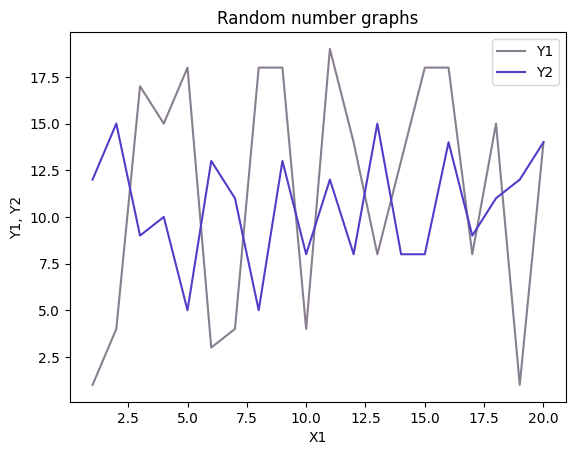

In [1]:
import random
import matplotlib.pyplot as plt

def plot_graphs(x_data, y_data, x_label, y_label, title, color=None):
    plt.figure()
    if all(type(arg) == list for arg in [x_data, y_data, y_label]):
        lx = len(x_data)
        if lx >= 1 and all(len(arg) == lx for arg in [y_data, y_label]):  
            for i in range(lx):
                color = tuple(random.random() for _ in range(3)) 
                plt.plot(x_data[i], y_data[i], color=color, label=y_label[i])
            plt.xlabel(x_label)
            plt.ylabel(", ".join(y_label))  
            plt.title(title)
            plt.legend()
        else:
            print('Something went wrong, review your arguments')
    else:
        plt.plot(x_data, y_data, color=color)
        plt.ylabel(y_label)
        plt.xlabel(x_label)
        plt.title(title)
        plt.xlim([min(x_data), max(x_data)])
        plt.grid(True)  
    plt.show()


def get_data_csv(fn, colx, coly, sep=","):
    with open(fn, "r") as f:
        header = f.readline().strip().split(sep)
        x_label = header[colx]
        y_label = header[coly]

        x_data, y_data = [], []
        for line in f:
            parts = line.strip().split(sep)
            try:
                x_data.append(float(parts[colx]))
                y_data.append(float(parts[coly]))
            except ValueError:
                continue
    return x_data, y_data, x_label, y_label


if __name__ == "__main__":
    user_fn = input("Enter CSV filename(s), separated by ',' : ")
    user_colx = input("Enter respective x-column(s), separated by ',' : ")
    user_coly = input("Enter respective y-column(s), separated by ',' : ")
    user_title = input("Enter title: ")

    fn = [f.strip() for f in user_fn.split(',')]                    
    colx = [int(c.strip()) for c in user_colx.split(',')]         
    coly = [int(c.strip()) for c in user_coly.split(',')]          
    
    if len(fn) != len(colx) or len(fn) != len(coly):
        print("Error: number of files, x-columns, and y-columns must match.")
        exit(1)

    if len(fn) == 1:
        x_data, y_data, x_label, y_label = get_data_csv(fn[0], colx[0], coly[0])
    else:
        x_data, y_data, y_label = [], [], []
        x_label = None                                              
        for i in range(len(fn)):
            auxx, auxy, auxlbl, auxylbl = get_data_csv(fn[i], colx[i], coly[i])
            x_data.append(auxx)
            y_data.append(auxy)
            y_label.append(auxylbl)
            if x_label is None:
                x_label = auxlbl

    plot_graphs(x_data, y_data, x_label, y_label, user_title)

In [ ]:
#LESSON 5 Challenge
from sympy import symbols, Eq, solve
s, t, u, v, w, x, y = symbols('s t u v w x y')
eq1 = Eq(2*s - 7*t + 3*u + 5*v - 7*w + 11*x + 8*y, 114)
eq2 = Eq(5*s + 7*t - u + 9*v - 6*w + 3*x - 5*y, -11)
eq3 = Eq(13*s + 11*t + 8*u + 7*v + 4*w + 2*x + y, -25)
eq4 = Eq(12*s + t + 6*u + 5*v + 9*w + 3*x + 11*y, -37)
eq5 = Eq(s - 4*t + 7*u - 3*v + 9*w - 2*x + 6*y, 4)
eq6 = Eq(4*s + t - 6*u - 3*v + 8*w - 7*x - 4*y, -91)
eq7 = Eq(-7*s - 2*t + 5*u + v + 9*w + 3*x - 4*y, -50)

solution = solve((eq1, eq2, eq3, eq4, eq5, eq6, eq7), (s, t, u, v, w, x, y))
print(solution)  


{s: 5, t: -7, u: 8, v: -6, w: -9, x: 2, y: -3}


In [10]:
import numpy as np

A = np.array([
    [2, -7, 3, 5, -7, 11, 8],
    [5, 7, -1, 9, -6, 3, -5],
    [13, 11, 8, 7, 4, 2, 1],
    [12, 1, 6, 5, 9, 3, 11],
    [1, -4, 7, -3, 9, -2, 6],
    [4, 1, -6, -3, 8, -7, -4],
    [-7, -2, 5, 1, 9, 3, -4]
])

b = np.array([114, -11, -25, -37, 4, -91, -50])

solution = np.linalg.solve(A, b)
print(solution)  


[ 5. -7.  8. -6. -9.  2. -3.]
